# Proyek Analisis Data: Air Quality Dataset (Beijing Multi-Site Air-Quality)
- **Nama:** Weka Surajati Sudanta
- **Email:** weka29januari@gmail.com
- **ID Dicoding:** surajati

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

### PERTANYAAN BISNIS 

- **Pertanyaan 1:** Stasiun mana yang memiliki rata-rata konsentrasi PM2.5 tertinggi selama periode 2013-2017, sehingga perlu menjadi prioritas kebijakan pengendalian polusi?
- **Pertanyaan 2:** Bagaimana pola musiman (bulanan) rata-rata konsentrasi PM2.5 dan PM10 di seluruh stasiun selama periode 2013-2017, dan bulan apa yang membutuhkan kewaspadaan ekstra?

## Import Semua Packages/Library yang Digunakan

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import glob

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

## Data Wrangling

### Gathering Data

#### Load Seluruh Dataset Stasiun Pemantauan

In [18]:
# Mengumpulkan seluruh file CSV dari 12 stasiun pemantauan kualitas udara Beijing
file_list = sorted(glob.glob('data/PRSA_Data_*.csv'))
print(f"Jumlah file yang ditemukan: {len(file_list)}")

df_list = [pd.read_csv(file) for file in file_list]
all_df = pd.concat(df_list, ignore_index=True)

print("Ukuran data gabungan:", all_df.shape)
all_df.head()

Jumlah file yang ditemukan: 12
Ukuran data gabungan: (420768, 18)


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


**Insight:**
- Dataset terdiri dari 12 file CSV, masing-masing mewakili satu stasiun pemantauan kualitas udara di wilayah Beijing.
- Setelah digabungkan, total data mencapai 420.768 baris pengamatan per jam, mencakup periode 1 Maret 2013 hingga 28 Februari 2017.
- Setiap baris berisi konsentrasi enam polutan udara (PM2.5, PM10, SO2, NO2, CO, O3) beserta data cuaca pendukung (suhu, tekanan udara, titik embun, curah hujan, arah dan kecepatan angin).

### Assessing Data

#### Identifying Missing Value, Duplikasi, dan Invalid Value

In [19]:
# Mengecek dimensi, tipe data, dan ringkasan umum
print(all_df.info())
print("\nJumlah data duplikat:", all_df.duplicated().sum())

# Mengecek missing value pada setiap kolom
print("\nJumlah missing value per kolom:")
print(all_df.isna().sum())

# Mengecek proporsi missing value pada kolom polutan utama
print("\nPersentase missing value PM2.5:", round(all_df['PM2.5'].isna().mean()*100, 2), "%")

# Mengecek potensi nilai tidak wajar (negatif) pada kolom polutan
pollutant_cols = ['PM2.5','PM10','SO2','NO2','CO','O3']
for col in pollutant_cols:
    print(f"Nilai negatif pada {col}:", (all_df[col] < 0).sum())

all_df[pollutant_cols].describe()

<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 62.1 MB
None

Jumlah data duplikat: 0

Jumlah missing value per kolo

,PM2.5,PM10,SO2,NO2,CO,O3
count,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000
mean,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271
std,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607
min,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200
25%,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000
50%,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000
75%,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000
max,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000


**Steps to Take:**
- Membentuk kolom datetime dari kolom year, month, day, hour agar data dapat diurutkan dan dianalisis sebagai deret waktu.
- Menangani missing value pada kolom polutan dan cuaca menggunakan interpolasi linear per stasiun (karena data bersifat time series per lokasi), lalu mengisi sisa nilai kosong di ujung data dengan median per stasiun.
- Menangani missing value pada kolom arah angin (wd) dengan modus per stasiun.
- Tidak ditemukan data duplikat maupun nilai negatif pada kolom polutan, sehingga tidak diperlukan penanganan untuk kedua isu tersebut.

**Insight:**
- Tidak ditemukan baris data duplikat pada dataset gabungan.
- Missing value ditemukan pada seluruh kolom polutan dan cuaca, dengan proporsi terbesar pada kolom CO (sekitar 4,9%) dan proporsi PM2.5 relatif kecil (sekitar 2,08%).
- Tidak ditemukan nilai negatif pada kolom polutan, menandakan tidak ada kesalahan input yang bersifat impossible value pada kolom tersebut.

### Cleaning Data

#### Fixing Missing Value pada Kolom Polutan dan Cuaca

In [20]:
# Membentuk kolom datetime
all_df['datetime'] = pd.to_datetime(all_df[['year','month','day','hour']])
all_df = all_df.drop(columns=['No'])
all_df = all_df.sort_values(['station','datetime']).reset_index(drop=True)

# Menangani missing value kolom numerik dengan interpolasi per stasiun
num_cols = ['PM2.5','PM10','SO2','NO2','CO','O3','TEMP','PRES','DEWP','RAIN','WSPM']
for col in num_cols:
    all_df[col] = all_df.groupby('station')[col].transform(lambda s: s.interpolate(limit_direction='both'))
    all_df[col] = all_df[col].fillna(all_df.groupby('station')[col].transform('median'))

# Menangani missing value kolom arah angin dengan modus per stasiun
all_df['wd'] = all_df.groupby('station')['wd'].transform(
    lambda s: s.fillna(s.mode().iloc[0] if not s.mode().empty else 'N')
)

print("Total missing value setelah cleaning:", all_df.isna().sum().sum())
all_df.info()

Total missing value setelah cleaning: 0
<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   year      420768 non-null  int64         
 1   month     420768 non-null  int64         
 2   day       420768 non-null  int64         
 3   hour      420768 non-null  int64         
 4   PM2.5     420768 non-null  float64       
 5   PM10      420768 non-null  float64       
 6   SO2       420768 non-null  float64       
 7   NO2       420768 non-null  float64       
 8   CO        420768 non-null  float64       
 9   O3        420768 non-null  float64       
 10  TEMP      420768 non-null  float64       
 11  PRES      420768 non-null  float64       
 12  DEWP      420768 non-null  float64       
 13  RAIN      420768 non-null  float64       
 14  wd        420768 non-null  str           
 15  WSPM      420768 non-null  float64       
 16  station  

**Insight:**
- Seluruh missing value pada kolom numerik dan kategorikal telah tertangani, sehingga total missing value pada dataset menjadi 0.
- Kolom datetime yang baru dibentuk memungkinkan data dianalisis sebagai deret waktu per stasiun maupun secara agregat bulanan.

## Exploratory Data Analysis (EDA)

### Explore Rata-rata Polusi Antar Stasiun dan Pola Musiman

In [21]:
# Statistik deskriptif keseluruhan
print(all_df[['PM2.5','PM10','SO2','NO2','CO','O3']].describe())

# Rata-rata PM2.5 per stasiun
station_avg = all_df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)
print("\nRata-rata PM2.5 per stasiun:")
print(station_avg)

# Rata-rata PM2.5 dan PM10 per bulan (seluruh stasiun)
monthly_avg = all_df.groupby('month')[['PM2.5','PM10']].mean()
print("\nRata-rata bulanan PM2.5 dan PM10:")
print(monthly_avg)

               PM2.5           PM10            SO2            NO2  \
count  420768.000000  420768.000000  420768.000000  420768.000000   
mean       79.839718     104.910268      15.913090      50.599018   
std        80.950217      92.431422      21.896609      35.171921   
min         2.000000       2.000000       0.285600       1.026500   
25%        20.000000      36.000000       3.000000      23.000000   
50%        55.000000      82.000000       7.000000      43.000000   
75%       111.000000     145.000000      20.000000      71.000000   
max       999.000000     999.000000     500.000000     290.000000   

                  CO             O3  
count  420768.000000  420768.000000  
mean     1235.682649      57.237872  
std      1161.790893      57.135195  
min       100.000000       0.214200  
25%       500.000000      10.000000  
50%       900.000000      44.000000  
75%      1500.000000      82.000000  
max     10000.000000    1071.000000  

Rata-rata PM2.5 per stasiun:
statio

**Insight:**
- Stasiun Dongsi, Nongzhanguan, dan Wanshouxigong konsisten memiliki rata-rata PM2.5 tertinggi (di atas 85 µg/m³), sementara stasiun Dingling dan Huairou yang berada di area pinggiran (suburban/background) memiliki rata-rata PM2.5 terendah.
- Rata-rata PM2.5 dan PM10 menunjukkan pola musiman yang jelas, meningkat tajam pada bulan-bulan musim dingin (Desember-Maret) dan menurun pada musim panas (Juli-September), konsisten dengan periode musim pemanas ruangan (heating season) di Beijing.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Stasiun dengan Rata-rata Konsentrasi PM2.5 Tertinggi

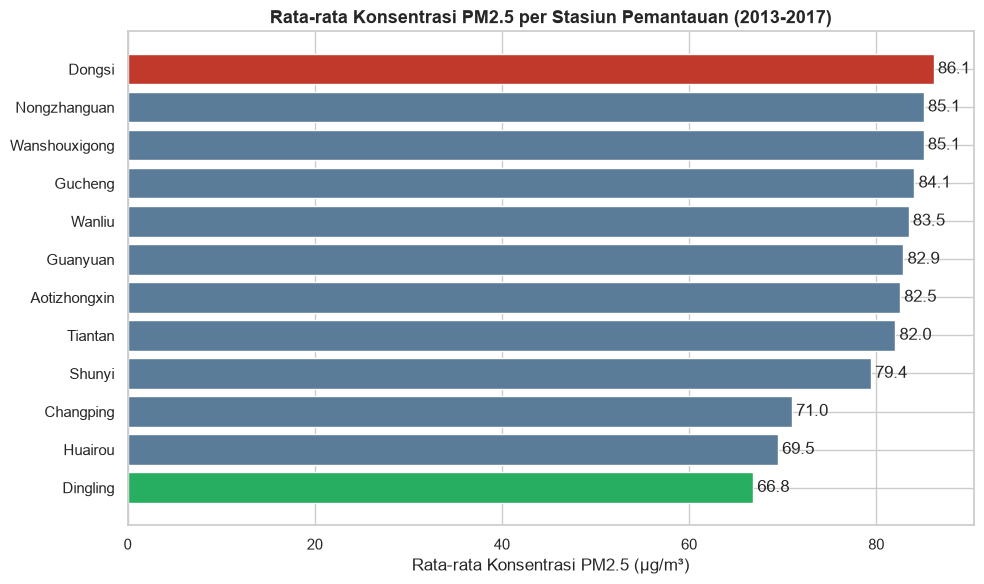

In [22]:
station_avg = all_df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)

colors = ['#c0392b' if v == station_avg.max() else ('#27ae60' if v == station_avg.min() else '#5b7c99') for v in station_avg.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(station_avg.index[::-1], station_avg.values[::-1], color=colors[::-1])
ax.set_xlabel('Rata-rata Konsentrasi PM2.5 (µg/m³)')
ax.set_title('Rata-rata Konsentrasi PM2.5 per Stasiun Pemantauan (2013-2017)', fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.1f', padding=3)
plt.tight_layout()
plt.show()

### Pertanyaan 2: Pola Musiman Konsentrasi PM2.5 dan PM10

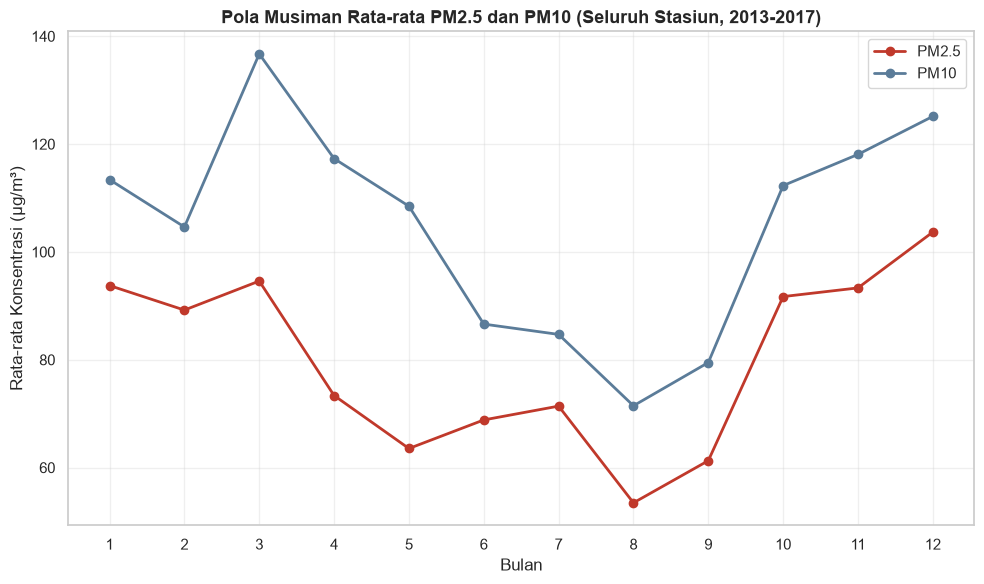

In [23]:
monthly_avg = all_df.groupby('month')[['PM2.5','PM10']].mean()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(monthly_avg.index, monthly_avg['PM2.5'], marker='o', label='PM2.5', color='#c0392b', linewidth=2)
ax.plot(monthly_avg.index, monthly_avg['PM10'], marker='o', label='PM10', color='#5b7c99', linewidth=2)
ax.set_xticks(range(1,13))
ax.set_xlabel('Bulan')
ax.set_ylabel('Rata-rata Konsentrasi (µg/m³)')
ax.set_title('Pola Musiman Rata-rata PM2.5 dan PM10 (Seluruh Stasiun, 2013-2017)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**
- Visualisasi mengonfirmasi bahwa stasiun Dongsi memiliki beban polusi PM2.5 tertinggi secara konsisten, menjadikannya prioritas utama untuk intervensi kebijakan seperti pembatasan kendaraan atau pengawasan emisi industri di sekitarnya.
- Kedua polutan (PM2.5 dan PM10) memuncak pada Desember-Januari dan mencapai titik terendah pada Agustus, menunjukkan bahwa kebijakan pengendalian polusi perlu diperketat khususnya pada periode musim dingin.

## Analisis Lanjutan (Opsional)

Pada bagian ini diterapkan dua teknik analisis lanjutan tanpa menggunakan algoritma machine learning:

1. **Binning (Manual Grouping)** — mengelompokkan setiap pengamatan PM2.5 ke dalam kategori kualitas udara (Baik, Sedang, Tidak Sehat bagi Kelompok Sensitif, Tidak Sehat, Sangat Tidak Sehat, Berbahaya) berdasarkan ambang batas baku mutu. Tujuannya untuk melihat seberapa sering tiap stasiun berada pada kondisi udara yang membahayakan kesehatan.
2. **Geospatial Analysis** — memetakan rata-rata PM2.5 tiap stasiun berdasarkan lokasi geografisnya menggunakan folium. Tujuannya untuk mengidentifikasi pola sebaran polusi secara spasial di wilayah Beijing.

Persentase waktu dengan kategori Tidak Sehat ke atas per stasiun:
station
Dongsi           17.111567
Nongzhanguan     16.971823
Wanshouxigong    16.658111
Wanliu           16.301620
Aotizhongxin     16.022131
Gucheng          15.890942
Tiantan          15.808236
Guanyuan         15.714123
Shunyi           15.297741
Changping        12.622633
Dingling         11.901095
Huairou          11.824093
Name: kategori_pm25, dtype: float64


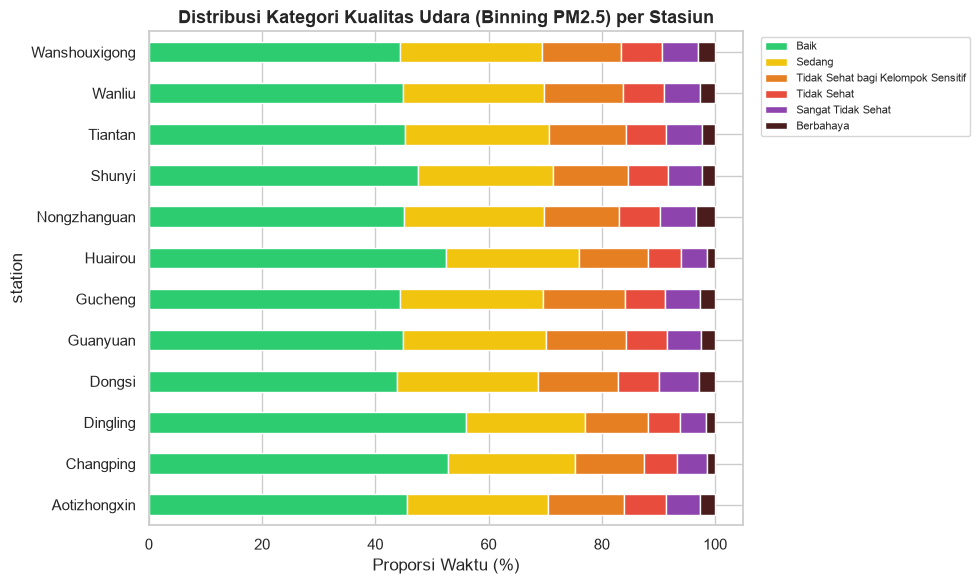

In [24]:

# Teknik Analisis Lanjutan 1: Binning (Manual Grouping) kategori kualitas udara
# Tujuan: mengelompokkan setiap pengamatan PM2.5 ke dalam kategori kualitas udara
# berbasis ambang batas baku mutu, tanpa menggunakan algoritma machine learning.

def kategori_pm25(x):
    if x <= 50:
        return 'Baik'
    elif x <= 100:
        return 'Sedang'
    elif x <= 150:
        return 'Tidak Sehat bagi Kelompok Sensitif'
    elif x <= 200:
        return 'Tidak Sehat'
    elif x <= 300:
        return 'Sangat Tidak Sehat'
    else:
        return 'Berbahaya'

all_df['kategori_pm25'] = all_df['PM2.5'].apply(kategori_pm25)

order = ['Baik','Sedang','Tidak Sehat bagi Kelompok Sensitif','Tidak Sehat','Sangat Tidak Sehat','Berbahaya']
persen_tidak_sehat = (
    all_df.groupby('station')['kategori_pm25']
    .apply(lambda s: s.isin(['Tidak Sehat','Sangat Tidak Sehat','Berbahaya']).mean() * 100)
    .sort_values(ascending=False)
)
print("Persentase waktu dengan kategori Tidak Sehat ke atas per stasiun:")
print(persen_tidak_sehat)

crosstab = pd.crosstab(all_df['station'], all_df['kategori_pm25'], normalize='index')[order] * 100
crosstab.plot(kind='barh', stacked=True, figsize=(10,6),
              color=['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad','#4a1c1c'])
plt.xlabel('Proporsi Waktu (%)')
plt.title('Distribusi Kategori Kualitas Udara (Binning PM2.5) per Stasiun', fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


# Teknik Analisis Lanjutan 2: Geospatial Analysis
# Tujuan: memetakan rata-rata PM2.5 tiap stasiun berdasarkan lokasi geografisnya
# untuk melihat pola sebaran polusi secara spasial di wilayah Beijing.

station_coords = {
    'Dongsi': (39.929, 116.417),
    'Tiantan': (39.886, 116.407),
    'Guanyuan': (39.929, 116.339),
    'Wanshouxigong': (39.878, 116.352),
    'Aotizhongxin': (39.982, 116.397),
    'Nongzhanguan': (39.937, 116.461),
    'Wanliu': (39.987, 116.287),
    'Gucheng': (39.914, 116.184),
    'Shunyi': (40.127, 116.655),
    'Changping': (40.217, 116.230),
    'Huairou': (40.328, 116.628),
    'Dingling': (40.292, 116.220),
}

station_avg = all_df.groupby('station')['PM2.5'].mean()

def marker_color(value):
    if value >= 85:
        return '#e74c3c'
    elif value >= 75:
        return '#e67e22'
    else:
        return '#27ae60'

m = folium.Map(location=[40.05, 116.4], zoom_start=9, tiles='OpenStreetMap')

for station, (lat, lon) in station_coords.items():
    avg_val = station_avg[station]
    folium.CircleMarker(
        location=[lat, lon],
        radius=10 + (avg_val / 10),
        color=marker_color(avg_val),
        fill=True,
        fill_color=marker_color(avg_val),
        fill_opacity=0.75,
        popup=f"{station}: {avg_val:.1f} µg/m³"
    ).add_to(m)

m

**Insight:**
- Binning menunjukkan bahwa stasiun-stasiun urban di pusat kota (Dongsi, Nongzhanguan, Wanshouxigong) menghabiskan sekitar 16-17% waktu pengamatan dalam kategori "Tidak Sehat" ke atas, sedangkan stasiun latar belakang/suburban (Dingling, Huairou, Changping) berada di kisaran 12%.
- Peta geospasial memperlihatkan pola spasial yang jelas: titik-titik dengan rata-rata PM2.5 tertinggi terkonsentrasi di area pusat/tenggara Beijing, sementara stasiun-stasiun di utara dan barat laut (area suburban seperti Dingling dan Huairou) relatif lebih bersih, mengindikasikan pengaruh kepadatan aktivitas perkotaan terhadap sebaran polusi.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Stasiun Dongsi memiliki rata-rata konsentrasi PM2.5 tertinggi (86,1 µg/m³) di antara 12 stasiun selama periode 2013-2017, diikuti oleh Nongzhanguan dan Wanshouxigong, sehingga ketiga stasiun ini merepresentasikan wilayah dengan beban polusi tertinggi dan perlu menjadi prioritas kebijakan pengendalian.
- **Conclusion pertanyaan 2:** Konsentrasi PM2.5 dan PM10 menunjukkan pola musiman yang konsisten, mencapai puncak pada Desember-Januari (di atas 90 µg/m³) dan titik terendah pada Agustus (sekitar 53 µg/m³), menandakan polusi udara di Beijing sangat dipengaruhi oleh aktivitas pemanas ruangan pada musim dingin.

**Rekomendasi Action Item:**
- Memprioritaskan pengetatan pengawasan emisi kendaraan dan industri di sekitar stasiun Dongsi, Nongzhanguan, dan Wanshouxigong, misalnya melalui pembatasan lalu lintas atau insentif transisi ke energi bersih.
- Meningkatkan intensitas kampanye kesehatan masyarakat dan pembatasan aktivitas luar ruangan pada periode Desember-Februari, saat konsentrasi PM2.5 secara konsisten berada pada level tertinggi sepanjang tahun.
- Mengembangkan sistem peringatan dini kualitas udara berbasis kategori binning (Baik hingga Berbahaya) yang terintegrasi dengan dashboard, agar masyarakat dapat memantau kondisi udara di stasiun terdekat secara real-time.